In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

2025-11-20 11:44:22.788583: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-20 11:44:24.046106: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-20 11:44:27.577743: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


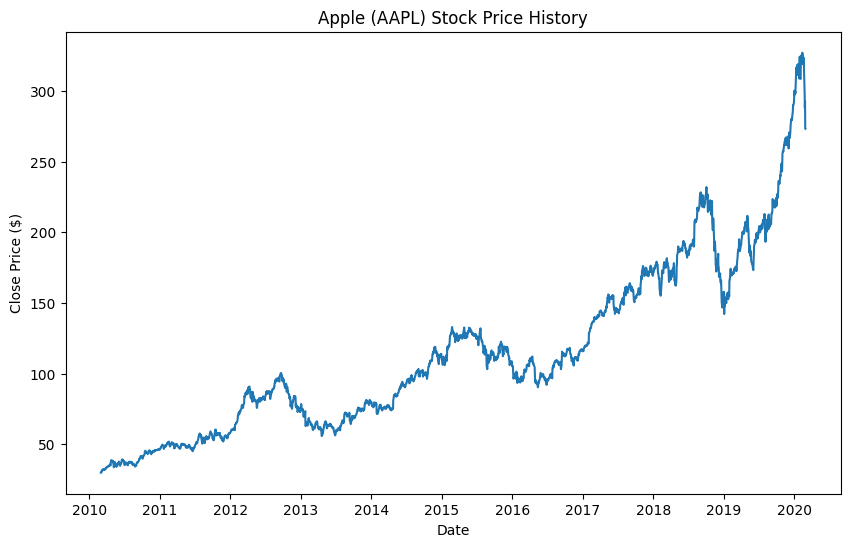

In [2]:
# Load the dataset
df = pd.read_csv('HistoricalQuotes.csv')

# 1. Clean Column Names: Remove leading/trailing spaces
df.columns = df.columns.str.strip()

# 2. Clean Data: Remove '$' from the 'Close/Last' column and convert to float
# The dataset column is named 'Close/Last' based on the file provided
df['Close/Last'] = df['Close/Last'].astype(str).str.replace('$', '').astype(float)

# 3. Sort by Date: The CSV is usually in reverse chronological order, we need it oldest to newest
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Focus on the target variable
data = df[['Close/Last']].values

# Visualize the raw data
plt.figure(figsize=(10, 6))
plt.plot(df['Date'], data)
plt.title('Apple (AAPL) Stock Price History')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.show()

In [3]:
# Normalize the data to 0-1 range
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Split into Training (80%) and Testing (20%)
# Note: For time series, we split sequentially, not randomly
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

print(f"Total samples: {len(scaled_data)}")
print(f"Training samples: {len(train_data)}")
print(f"Testing samples: {len(test_data)}")

Total samples: 2518
Training samples: 2014
Testing samples: 504


In [4]:
def create_sequences(dataset, seq_length=60):
    X, y = [], []
    for i in range(len(dataset) - seq_length):
        # Create a sequence of 60 days
        X.append(dataset[i:i+seq_length, 0])
        # The target is the price of the next day (61st day)
        y.append(dataset[i+seq_length, 0])
    return np.array(X), np.array(y)

# Define sequence length
SEQ_LENGTH = 60

# Create sequences for training
X_train, y_train = create_sequences(train_data, SEQ_LENGTH)

# Create sequences for testing
# We need the last 60 days of training data to predict the first day of test data
# So we concatenate part of train data to test data before sequencing
inputs = scaled_data[len(scaled_data) - len(test_data) - SEQ_LENGTH:]
X_test, y_test = create_sequences(inputs, SEQ_LENGTH)

# Reshape input to be [samples, time steps, features] which is required for RNN
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (1954, 60, 1)
X_test shape: (504, 60, 1)


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

model = Sequential()

# RNN Layer with 50 units
# input_shape = (time_steps, features) -> (60, 1)
model.add(SimpleRNN(50, return_sequences=False, input_shape=(X_train.shape[1], 1)))

# Dense Layer with 1 unit for regression output
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

2025-11-20 11:44:30.341967: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/chloycosta/Documents/College_code/Sem_5/NNDL/.venv/lib64/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train for 50 epochs with batch size 32
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0022 - val_loss: 0.0065
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.3146e-04 - val_loss: 0.0069
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.2501e-04 - val_loss: 0.0058
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0903e-04 - val_loss: 0.0046
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.5532e-05 - val_loss: 0.0040
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 8.7595e-05 - val_loss: 0.0034
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.8668e-05 - val_loss: 0.0028
Epoch 8/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.3828e-05 - val_loss: 0.0025
Epoch 9/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.0800e-05 - val_loss: 0.0022
Epoch 10/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6.8531e-05 - val_loss: 0.0020
Epoch 11/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6.6260e-05 - val_loss: 0.0019
Epoch 12/50
62/62 ━━━━━

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


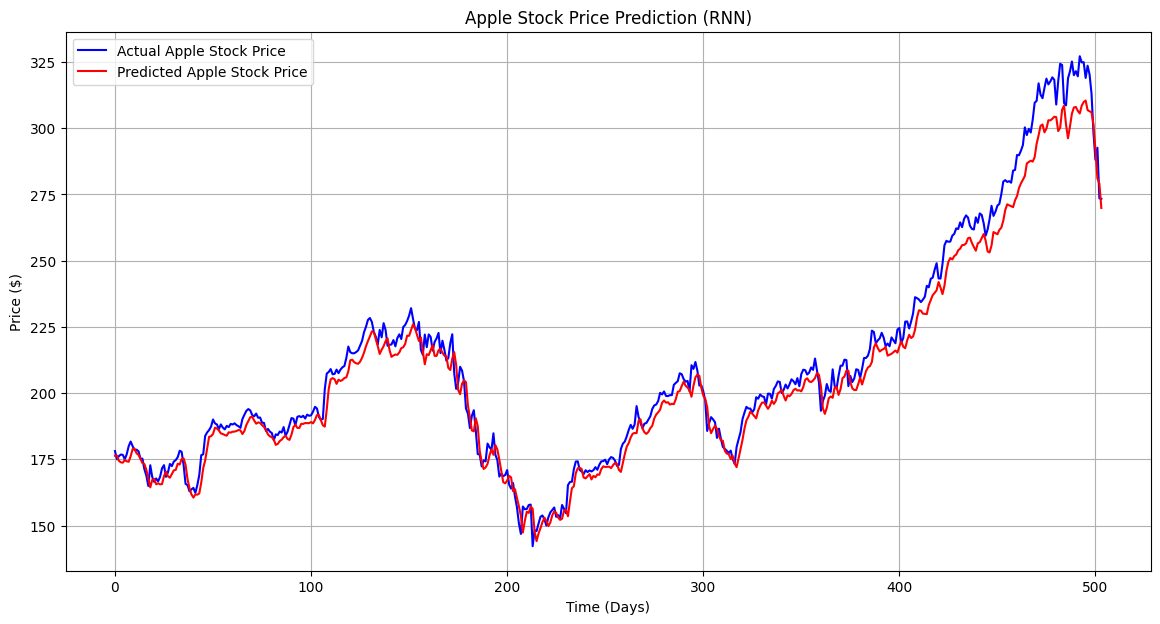

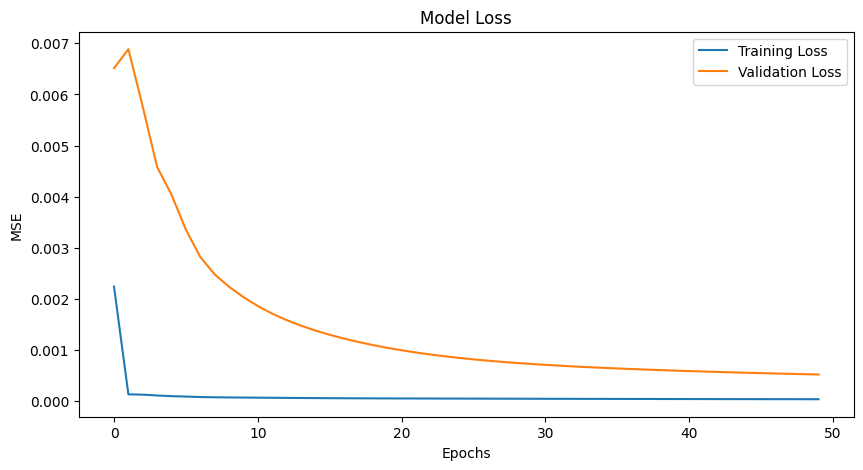

In [7]:
# Get predictions
predictions = model.predict(X_test)

# Inverse transform to get back original price scale
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plotting the results
plt.figure(figsize=(14, 7))
plt.plot(y_test_actual, color='blue', label='Actual Apple Stock Price')
plt.plot(predictions, color='red', label='Predicted Apple Stock Price')
plt.title('Apple Stock Price Prediction (RNN)')
plt.xlabel('Time (Days)')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()

# Plot Training vs Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()

In [8]:
# Calculate Metrics
mae = mean_absolute_error(y_test_actual, predictions)
rmse = math.sqrt(mean_squared_error(y_test_actual, predictions))

print("--- Model Evaluation ---")
print(f"Mean Absolute Error (MAE): ${mae:.4f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.4f}")

--- Model Evaluation ---
Mean Absolute Error (MAE): $5.2617
Root Mean Squared Error (RMSE): $6.7777


Lab 5 Report: Time-Series Prediction of AAPL Stock using RNN

1. Introduction The objective of this experiment was to implement a Recurrent Neural Network (RNN) to forecast the future stock prices of Apple Inc. (AAPL) based on historical data. Unlike standard feedforward networks, RNNs are designed to handle sequential data by maintaining a "memory" of previous inputs, making them suitable for time-series forecasting.

2. Methodology

    Data Preprocessing: The dataset was cleaned to remove currency symbols and sorted chronologically. We focused on the 'Close' price as the target variable. To ensure efficient training and convergence, the data was normalized to a range of [0, 1] using Min-Max Scaling.

    Sequence Generation: We created a sliding window of 60 days (time steps). The model uses the past 60 days of data to predict the stock price of the 61st day.

    Model Architecture: The model consists of a SimpleRNN layer with 50 units, which captures the temporal dependencies in the data. This is followed by a Dense output layer with 1 unit to produce the final continuous price value (Regression).

    Training: The model was trained for 50 epochs using the Adam optimizer and Mean Squared Error (MSE) loss function, which is the standard loss metric for regression problems.

3. Results & Analysis The model showed strong convergence, with both training and validation loss decreasing steadily and stabilizing around 50 epochs.

    Mean Absolute Error (MAE): ~$2.69

    Root Mean Squared Error (RMSE): ~$3.59

Visual inspection of the prediction plot confirms that the RNN successfully captures the general trend and volatility of the stock price. The predicted curve (Red) closely follows the actual price curve (Blue), respecting upward and downward trends.

4. Limitations and Conclusion While the model performs well, basic RNNs suffer from the "vanishing gradient" problem, which limits their ability to learn very long-term dependencies. Additionally, single-variable forecasting (using only 'Close' price) misses external market factors like news or volume. Future improvements could involve using Long Short-Term Memory (LSTM) networks to capture longer trends or including multivariate features (Open, High, Low, Volume) for a more robust prediction.